**23.1** Sử dụng thư viện Folium, bạn hãy xây dựng một bản đồ tương tác hiển thị vị trí của UEH hoặc trường Đại học đang theo học hoặc một địa điểm trung tâm được lựa chọn. Trên bản đồ cần thể hiện tối thiểu năm địa điểm công cộng lân cận như bệnh viện, trung tâm thương mại, bến xe hoặc cơ quan hành chính. Mỗi địa điểm phải được gắn marker có popup mô tả ngắn gọn thông tin. Bản đồ cần có khả năng phóng to, thu nhỏ và bật/tắt các lớp dữ liệu.

In [1]:
import folium

# ==================== KHOI TAO BAN DO ====================
ueh_b_coords = [10.7601, 106.6644]
m = folium.Map(location=ueh_b_coords, zoom_start=17)

# ==================== TAO CAC LAYER ====================
fg_main   = folium.FeatureGroup(name="Co so dao tao")
fg_public = folium.FeatureGroup(name="Dia diem cong cong lan can")

# Marker truong UEH
folium.Marker(
    location=ueh_b_coords,
    popup="<b>UEH - Co so B</b><br>Trung tam dao tao hien dai cua UEH",
    tooltip="Dai hoc Kinh te TP.HCM - Co so B",
    icon=folium.Icon(color="red", icon="university", prefix="fa")
).add_to(fg_main)

# ==================== CAC DIA DIEM LAN CAN ====================
nearby_locations = [
    {"name": "Benh vien Dai hoc Y Duoc",      "coord": [10.7554, 106.6655], "popup": "Benh vien tuyen trung uong hang dau",         "icon": "plus-square", "color": "blue"},
    {"name": "Hung Vuong Plaza",               "coord": [10.7571, 106.6640], "popup": "Trung tam thuong mai va giai tri lon",        "icon": "shopping-bag","color": "orange"},
    {"name": "San van dong Thong Nhat",        "coord": [10.7610, 106.6610], "popup": "Dia diem to chuc cac su kien the thao lon",  "icon": "trophy",      "color": "green"},
    {"name": "UBND Quan 10",                   "coord": [10.7748, 106.6635], "popup": "Co quan quan ly hanh chinh Quan 10",        "icon": "building",    "color": "cadetblue"},
    {"name": "Tram xe buyt Nguyen Tri Phuong", "coord": [10.7595, 106.6648], "popup": "Diem dung xe buyt ket noi cac quan trung tam","icon": "bus",         "color": "purple"},
]

for loc in nearby_locations:
    folium.Marker(
        location=loc["coord"],
        popup=f"<b>{loc['name']}</b><br>{loc['popup']}",
        tooltip=loc["name"],
        icon=folium.Icon(color=loc["color"], icon=loc["icon"], prefix="fa")
    ).add_to(fg_public)

# ==================== HOAN THIEN BAN DO ====================
fg_main.add_to(m)
fg_public.add_to(m)
folium.LayerControl().add_to(m)
m

**23.2** Sử dụng GeoPy, bạn hãy thu thập hoặc giả lập danh sách tối thiểu mười địa chỉ cụ thể. Thực hiện chuyển đổi các địa chỉ này sang tọa độ địa lý (vĩ độ, kinh độ) và tính khoảng cách từ mỗi địa chỉ đến một điểm trung tâm xác định trước. Kết quả cần được trực quan hóa trên bản đồ Folium, trong đó thể hiện rõ vị trí, khoảng cách và mối quan hệ không gian giữa các điểm.

In [2]:
import folium
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

# ==================== CAU HINH ====================
geolocator    = Nominatim(user_agent="my_map_app")
center_coords = [10.761229812265682, 106.6684313949965]  # UEH Co so B

addresses = [
    "Dinh Doc Lap, Quan 1, Ho Chi Minh City",
    "Nha tho Duc Ba, Quan 1, Ho Chi Minh City",
    "Cho Ben Thanh, Quan 1, Ho Chi Minh City",
    "Ho Con Rua, Quan 3, Ho Chi Minh City",
    "Benh vien Nhi Dong 1, Quan 10, Ho Chi Minh City",
    "San van dong Thong Nhat, Quan 10, Ho Chi Minh City",
    "Bao tang Chung tich Chien tranh, Quan 3, Ho Chi Minh City",
    "Thao Cam Vien, Quan 1, Ho Chi Minh City",
    "Landmark 81, Binh Thanh, Ho Chi Minh City",
    "Pho di bo Nguyen Hue, Quan 1, Ho Chi Minh City",
]

# ==================== KHOI TAO BAN DO ====================
m = folium.Map(location=center_coords, zoom_start=14)

folium.Marker(
    location=center_coords,
    popup="<b>TRUNG TAM: UEH CO SO B</b>",
    icon=folium.Icon(color="red", icon="star")
).add_to(m)

# ==================== GEOCODING & TINH KHOANG CACH ====================
print(f"Diem trung tam: {center_coords}\n")

for addr in addresses:
    try:
        loc = geolocator.geocode(addr)
        if loc:
            point_coords = (loc.latitude, loc.longitude)
            dist = geodesic(center_coords, point_coords).km
            print(f"- {addr}: {dist:.2f} km")
            folium.Marker(
                location=point_coords,
                popup=f"Dia chi: {addr}<br>Khoang cach: {dist:.2f} km",
                tooltip=addr,
                icon=folium.Icon(color="blue", icon="info-sign")
            ).add_to(m)
            folium.PolyLine(
                locations=[center_coords, point_coords],
                color="gray", weight=1.5
            ).add_to(m)
        time.sleep(1)  # Tranh rate-limit cua Nominatim
    except Exception as e:
        print(f"Loi khi xu ly '{addr}': {e}")
m

Diem trung tam: [10.761229812265682, 106.6684313949965]



- Cho Ben Thanh, Quan 1, Ho Chi Minh City: 3.87 km


- Benh vien Nhi Dong 1, Quan 10, Ho Chi Minh City: 0.87 km


- Thao Cam Vien, Quan 1, Ho Chi Minh City: 5.08 km
- Landmark 81, Binh Thanh, Ho Chi Minh City: 9.80 km


**23.3** Bạn hãy tạo một bản đồ nhiệt (heatmap) thể hiện mật độ phân bố của một hiện tượng không gian như khách hàng, đơn hàng, dân cư hoặc điểm giao dịch (dữ liệu có thể giả lập). Bản đồ phải cho phép người xem nhận biết trực quan các khu vực có mật độ cao và thấp, đồng thời giải thích ý nghĩa quản trị của các vùng nóng trên bản đồ.

In [3]:
import folium
from folium.plugins import HeatMap
import numpy as np

# ==================== GIA LAP DU LIEU ====================
# 3 cum mat do tuong ung 3 khu vuc trong diem tai TP.HCM
np.random.seed(42)
data = []

# Vung 1: Trung tam Q1-Q3 (mat do cao nhat)
for _ in range(250):
    data.append([10.7769 + np.random.normal(0, 0.015),
                 106.7009 + np.random.normal(0, 0.015), 1])

# Vung 2: Khu Nam Q7 (mat do trung binh)
for _ in range(150):
    data.append([10.7300 + np.random.normal(0, 0.01),
                 106.7100 + np.random.normal(0, 0.01), 0.8])

# Vung 3: Khu Bac (mat do thap)
for _ in range(100):
    data.append([10.8100 + np.random.normal(0, 0.02),
                 106.6800 + np.random.normal(0, 0.02), 0.5])

# ==================== VE HEATMAP ====================
m = folium.Map(location=[10.7769, 106.7009], zoom_start=12)
HeatMap(data, radius=15, blur=20, min_opacity=0.4).add_to(m)

# Marker chu thich cac vung nong
folium.Marker([10.7769, 106.7009], popup="Vung nong: Trung tam (Q1, Q3) - Mat do cao nhat").add_to(m)
folium.Marker([10.7300, 106.7100], popup="Vung nong: Khu Nam (Q7) - Mat do trung binh").add_to(m)
m

**Nhận xét:**
- Vùng Q1-Q3 có mật độ đơn hàng/khách hàng cao nhất, nên ưu tiên phân bổ xe và nhân lực vào khung giờ cao điểm tại đây.
- Q7 là vùng tiềm năng đang phát triển, cần mở thêm điểm trung chuyển.
- Các khu vực màu lạnh (xanh) cho thấy nhu cầu thấp, không nên triển khai thêm nguồn lực tránh lãng phí chi phí.

**23.4** Sử dụng GeoPandas, hãy đọc dữ liệu ranh giới hành chính (tỉnh, thành phố hoặc phường/xã) và kết hợp với một tập dữ liệu số tương ứng như dân số, doanh thu, số lượng đơn hàng hoặc mức độ tiêu thụ. Kết quả cần được thể hiện dưới dạng bản đồ choropleth, phản ánh sự khác biệt không gian giữa các khu vực và đưa ra nhận xét ngắn về ý nghĩa quản trị.

In [4]:
import geopandas as gpd
import json
import pandas as pd

print("Dang xu ly va ve ban do...")

# ==================== TAO DU LIEU GEOJSON ====================
districts_data = [
    {"name": "Quan 1",    "coords": [[106.6955,10.7769],[106.6992,10.7755],[106.7018,10.7770],[106.7005,10.7800],[106.6970,10.7805],[106.6942,10.7790],[106.6955,10.7769]]},
    {"name": "Quan 3",    "coords": [[106.6880,10.7830],[106.6915,10.7815],[106.6935,10.7835],[106.6920,10.7860],[106.6890,10.7855],[106.6875,10.7840],[106.6880,10.7830]]},
    {"name": "Quan 7",    "coords": [[106.7180,10.7380],[106.7250,10.7360],[106.7280,10.7400],[106.7260,10.7450],[106.7200,10.7440],[106.7170,10.7410],[106.7180,10.7380]]},
    {"name": "Quan 10",   "coords": [[106.6660,10.7720],[106.6700,10.7705],[106.6725,10.7725],[106.6710,10.7755],[106.6680,10.7750],[106.6665,10.7735],[106.6660,10.7720]]},
    {"name": "Binh Thanh","coords": [[106.7080,10.8010],[106.7140,10.7980],[106.7170,10.8020],[106.7150,10.8070],[106.7100,10.8060],[106.7070,10.8030],[106.7080,10.8010]]},
]
features = [{"type": "Feature", "properties": {"name": d["name"]},
             "geometry": {"type": "Polygon", "coordinates": [d["coords"]]}}
            for d in districts_data]
geojson_data = {"type": "FeatureCollection", "features": features}

with open("hcm_districts.geojson", "w", encoding="utf-8") as f:
    json.dump(geojson_data, f, ensure_ascii=False, indent=2)

# ==================== TAO DU LIEU CSV ====================
df = pd.DataFrame({
    "District":  ["Quan 1", "Quan 3", "Quan 7", "Quan 10", "Binh Thanh"],
    "Dan_So":    [142000, 190000, 280000, 125000, 470000],
    "Don_Hang":  [18500,  12100,  23800,  9800,   32400],
    "Doanh_Thu": [185.5,  121.2,  238.7,  98.3,   324.9],
})
df.to_csv("hcm_districts.csv", index=False, encoding="utf-8-sig")

# ==================== MERGE VA VE BAN DO ====================
hcm_map = gpd.read_file("hcm_districts.geojson")
df_csv  = pd.read_csv("hcm_districts.csv")

# Chuan hoa chuoi truoc khi merge
hcm_map["name"]    = hcm_map["name"].str.strip()
df_csv["District"] = df_csv["District"].str.strip()

ghep = hcm_map.merge(df_csv, left_on="name", right_on="District")

# Ve choropleth tuong tac bang .explore() cua GeoPandas
map_tuong_tac = ghep.explore(
    column="Dan_So",
    cmap="YlOrRd",
    tooltip=["name", "Dan_So", "Doanh_Thu"],
    popup=True,
    tiles="CartoDB positron",
)
map_tuong_tac
# map_tuong_tac.save("hcm_interactive_map.html")

Dang xu ly va ve ban do...


**Nhận xét:**
- Bình Thạnh có dân số và đơn hàng lớn nhất, là thị trường ưu tiên mở rộng kho hàng.
- Quận 10 có dân số và doanh thu thấp nhất trong 5 quận, cần điều tra nguyên nhân trước khi đầu tư thêm.
- Choropleth giúp nhà quản lý nhìn tổng thể chênh lệch không gian chỉ trong một biểu đồ thay vì đọc bảng số liệu.

**23.5** Bạn hãy xây dựng mô hình phân tích vùng phục vụ (service area) cho một trung tâm phân phối, kho hàng hoặc trạm dịch vụ. Sử dụng dữ liệu tọa độ để vẽ các vòng bán kính phục vụ khác nhau (ví dụ: 3 km, 5 km và 10 km) và trực quan hóa trên bản đồ. Bài làm cần đánh giá khả năng tiếp cận khách hàng của từng vùng và đề xuất phạm vi hoạt động tối ưu.

In [5]:
import folium

# ==================== CAU HINH ====================
center = [10.7601, 106.6644]  # UEH Co so B - gia lap vi tri kho tong

zones = [
    {"radius": 3000,  "color": "green",  "label": "Vung uu tien (3 km) - Giao nhanh < 15 phut"},
    {"radius": 5000,  "color": "orange", "label": "Vung tieu chuan (5 km) - Giao < 30 phut"},
    {"radius": 10000, "color": "red",    "label": "Vung mo rong (10 km) - Chi phi cao hon"},
]

# ==================== VE BAN DO ====================
m = folium.Map(location=center, zoom_start=13)

for zone in zones:
    folium.Circle(
        location=center,
        radius=zone["radius"],
        color=zone["color"],
        fill=True,
        fill_opacity=0.15,
        popup=zone["label"],
        tooltip=zone["label"],
    ).add_to(m)

folium.Marker(center, popup="KHO TONG", icon=folium.Icon(color="black", icon="home")).add_to(m)
m

**Nhận xét:**
- Vùng 3 km (xanh): Giao hàng trong 15 phút, phù hợp chiến lược same-hour delivery.
- Vùng 5 km (cam): Cân bằng chi phí và thời gian, đây là phạm vi hoạt động tối ưu nhất.
- Vùng 10 km (đỏ): Chi phí logistics tăng cao, nên cân nhắc thêm kho vệ tinh để phục vụ điểm xa.

**23.6** Sử dụng OSMnx, hãy tải dữ liệu mạng lưới giao thông đường bộ của một khu vực đô thị cụ thể. Trực quan hóa mạng đường trên bản đồ và thực hiện một số phân tích cơ bản như số lượng nút giao, chiều dài đường trung bình hoặc mật độ mạng. Trình bày vai trò của dữ liệu mạng giao thông trong các hệ thống AI đô thị thông minh.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.0 MB/s eta 0:00:00
So luong nut giao:            989
So luong doan duong:          2088
Chieu dai trung binh moi doan: 79.09 m


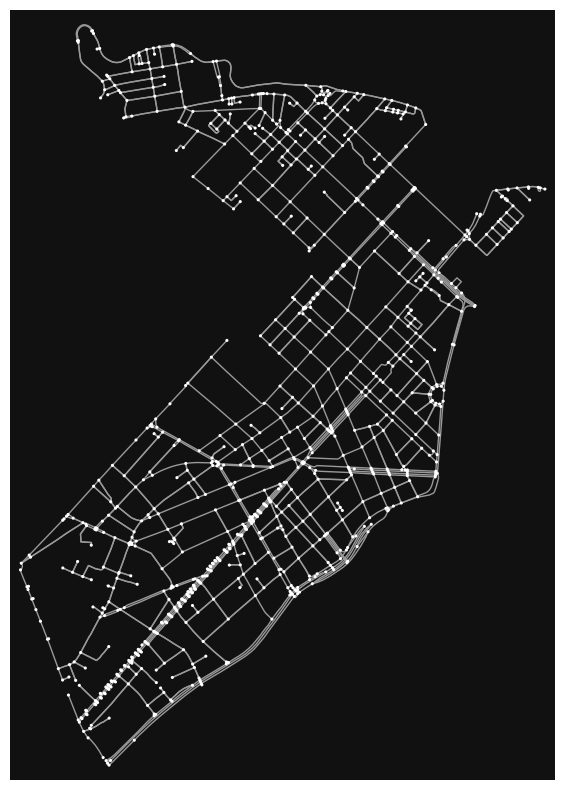

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [6]:
!pip install osmnx -q
import osmnx as ox

# ==================== TAI MANG LUOI DUONG BO ====================
place_name = "District 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type="drive")

# ==================== THONG KE CO BAN ====================
# Luu y: ox.basic_stats() da bi deprecated tu OSMnx v1.3+
# Su dung truc tiep graph_to_gdfs de lay thong ke
nodes, edges = ox.graph_to_gdfs(graph)

print(f"So luong nut giao:            {len(nodes)}")
print(f"So luong doan duong:          {len(edges)}")
print(f"Chieu dai trung binh moi doan: {edges['length'].mean():.2f} m")

# ==================== TRUC QUAN HOA ====================
ox.plot_graph(graph, figsize=(10, 10), node_size=5)

**Nhận xét - Vai trò mạng giao thông trong AI đô thị thông minh:**
- **Định tuyến & tối ưu hóa:** Dữ liệu đường là nền tảng cho các thuật toán tìm đường (Dijkstra, A*) trong ứng dụng gọi xe, giao hàng.
- **Dự báo tắc nghẽn:** Kết hợp với dữ liệu tốc độ thực tế (GPS probe data), AI có thể dự đoán điểm nghẽn và đề xuất tuyến thay thế.
- **Quy hoạch đô thị:** Phân tích mật độ mạng lưới giúp xác định khu vực thiếu hạ tầng giao thông để ưu tiên đầu tư.
- **Điều phối phương tiện tự hành:** Bản đồ vector đường là đầu vào bắt buộc cho hệ thống navigation của xe tự lái.

**23.7** Kết hợp OSMnx và NetworkX, bạn hãy xây dựng chương trình tìm đường đi ngắn nhất giữa hai địa điểm bất kỳ trong khu vực nghiên cứu. So sánh kết quả giữa ít nhất hai thuật toán khác nhau (ví dụ: Dijkstra và A*). Tuyến đường tìm được cần được hiển thị trực quan trên bản đồ và phân tích ưu - nhược điểm của từng phương pháp.

--- KET QUA DIJKSTRA ---
So nut di qua: 44
Tong chieu dai: 4529.3 m
Thoi gian chay: 0.00428 giay

--- KET QUA A* ---
So nut di qua: 44
Tong chieu dai: 4529.3 m
Thoi gian chay: 0.00295 giay

=> Nhan xet: A* nhanh hon Dijkstra khoang 1.5 lan tren cung 1 lo trinh!


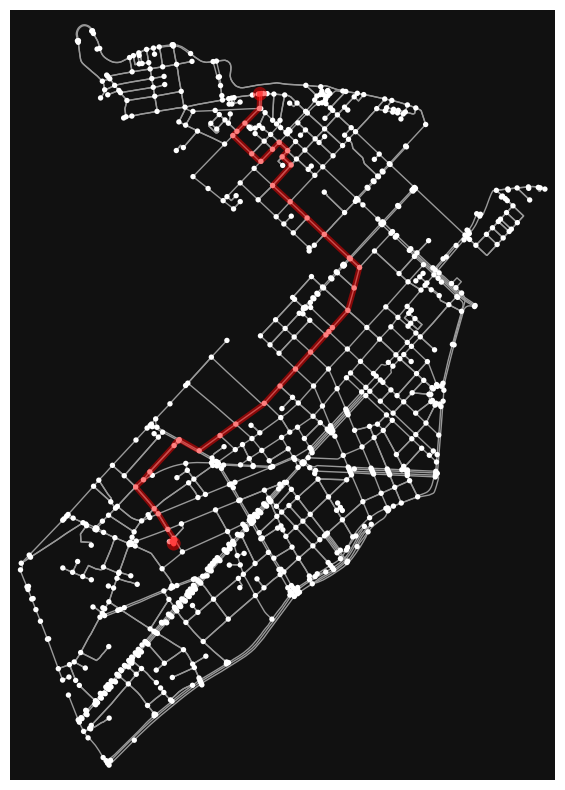

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [22]:
import networkx as nx
import osmnx as ox
import time
import math

# ==================== CAU HINH ====================
place_name = "District 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type="drive")

# ==================== CHON DIEM DAU & CUOI ====================
nodes = list(graph.nodes())
orig_node = nodes[0]
dest_node = nodes[-1]

# ==================== HAM HEURISTIC CHO A* ====================
# A* can mot ham uoc luong khoang cach tu nut hien tai (u) den dich (v)
# Neu khong co ham nay, A* se chay cham y nhu Dijkstra
def dist_heuristic(u, v):
    x1, y1 = graph.nodes[u]['x'], graph.nodes[u]['y']
    x2, y2 = graph.nodes[v]['x'], graph.nodes[v]['y']
    # Tinh khoang cach Euclid xap xi (1 do ~ 111139 met) de lam Heuristic
    return math.hypot(x1 - x2, y1 - y2) * 111139

# ==================== THUAT TOAN & DO THOI GIAN ====================

# 1. Dijkstra
start_time_d = time.time()
path_dijkstra = nx.shortest_path(graph, orig_node, dest_node,
                                 weight="length", method="dijkstra")
time_dijkstra = time.time() - start_time_d

# 2. A* (Da tich hop ham Heuristic dinh huong)
start_time_a = time.time()
path_astar = nx.astar_path(graph, orig_node, dest_node,
                           heuristic=dist_heuristic, weight="length")
time_astar = time.time() - start_time_a

# ==================== SO SANH KET QUA ====================
len_dijkstra = nx.shortest_path_length(graph, orig_node, dest_node,
                                       weight="length", method="dijkstra")
len_astar    = sum(graph[u][v][0].get("length", 0)
                   for u, v in zip(path_astar[:-1], path_astar[1:]))

print("--- KET QUA DIJKSTRA ---")
print(f"So nut di qua: {len(path_dijkstra)}")
print(f"Tong chieu dai: {len_dijkstra:.1f} m")
print(f"Thoi gian chay: {time_dijkstra:.5f} giay\n")

print("--- KET QUA A* ---")
print(f"So nut di qua: {len(path_astar)}")
print(f"Tong chieu dai: {len_astar:.1f} m")
print(f"Thoi gian chay: {time_astar:.5f} giay\n")

if time_astar < time_dijkstra:
    print(f"=> Nhan xet: A* nhanh hon Dijkstra khoang {time_dijkstra/time_astar:.1f} lan tren cung 1 lo trinh!")
else:
    print("=> Ban do Quan 1 co the qua nho nen chua thay ro khoang cach ve thoi gian. Hay thu 'Ho Chi Minh City, Vietnam'.")

# ==================== TRUC QUAN HOA ====================
ox.plot_graph_route(graph, path_dijkstra, route_color="red",
                    route_linewidth=4, figsize=(10, 10))

**Nhận xét - So sánh Dijkstra vs A*:**

| Tiêu chí | Dijkstra | A* |
|---|---|---|
| **Độ chính xác** | Luôn tìm ra đường tối ưu | Tối ưu nếu heuristic admissible |
| **Tốc độ** | Chậm hơn (duyệt toàn bộ đồ thị) | Nhanh hơn nhờ heuristic định hướng |
| **Bộ nhớ** | Tốn nhiều hơn | Tốn ít hơn trong thực tế |
| **Phù hợp khi** | Cần đảm bảo tối ưu tuyệt đối | Mạng lớn, cần phản hồi nhanh (real-time) |

Trong ứng dụng gọi xe thực tế, A* thường được ưu tiên vì cho phép phản hồi ngay lập tức với bản đồ thành phố có hàng triệu nút.

**23.8** Bạn hãy mô phỏng một hệ thống gọi xe công nghệ đơn giản. Trong đó, vị trí khách hàng và xe được biểu diễn bằng tọa độ trên bản đồ. Áp dụng một phương pháp AI hoặc heuristic để gán xe phù hợp nhất cho từng khách hàng dựa trên khoảng cách hoặc thời gian di chuyển. Toàn bộ quá trình ghép xe và khách cần được trực quan hóa trên bản đồ.

In [9]:
import folium
import pandas as pd
import numpy as np
from scipy.spatial import distance

# ==================== GIA LAP DU LIEU ====================
customers = pd.DataFrame({
    "id":  ["Khach 1", "Khach 2", "Khach 3"],
    "lat": [10.7760,    10.7710,   10.7750],
    "lon": [106.6660,   106.6620,  106.6700],
})

drivers = pd.DataFrame({
    "id":  ["Xe A", "Xe B", "Xe C", "Xe D", "Xe E"],
    "lat": [10.7780, 10.7700, 10.7740, 10.7790, 10.7720],
    "lon": [106.6680, 106.6610, 106.6650, 106.6600, 106.6690],
})

# ==================== KHOI TAO BAN DO ====================
m = folium.Map(location=[10.7745, 106.6640], zoom_start=15)

# ==================== HEURISTIC: GAN XE GAN NHAT ====================
print("--- QUA TRINH GHEP XE ---")
assigned = []

for _, cust in customers.iterrows():
    c_pt  = (cust["lat"], cust["lon"])
    avail = drivers[~drivers["id"].isin(assigned)].copy()
    avail["dist"] = avail.apply(
        lambda r: distance.euclidean(c_pt, (r["lat"], r["lon"])), axis=1)
    best = avail.loc[avail["dist"].idxmin()]
    assigned.append(best["id"])
    print(f"  {cust['id']} -> {best['id']} (khoang cach: {best['dist']:.5f})")

    # Marker khach hang
    folium.Marker(c_pt, popup=cust["id"],
                  icon=folium.Icon(color="red", icon="user", prefix="fa")).add_to(m)
    # Marker tai xe duoc chon
    d_pt = (best["lat"], best["lon"])
    folium.Marker(d_pt, popup=f"Tai xe: {best['id']}",
                  icon=folium.Icon(color="blue", icon="car", prefix="fa")).add_to(m)
    # Duong noi khach - xe
    folium.PolyLine([c_pt, d_pt], color="green", weight=3,
                    dash_array="5,10", tooltip=f"Don {cust['id']}").add_to(m)

# Tai xe con lai (chua duoc gan)
for _, drv in drivers[~drivers["id"].isin(assigned)].iterrows():
    folium.Marker([drv["lat"], drv["lon"]],
                  popup=f"Xe ranh: {drv['id']}",
                  icon=folium.Icon(color="gray", icon="car", prefix="fa")).add_to(m)
m

--- QUA TRINH GHEP XE ---
  Khach 1 -> Xe C (khoang cach: 0.00224)
  Khach 2 -> Xe B (khoang cach: 0.00141)
  Khach 3 -> Xe E (khoang cach: 0.00316)


**23.9** Sử dụng thuật toán phân cụm trong học máy, bạn hãy phân cụm dữ liệu vị trí khách hàng hoặc đơn hàng. Trên cơ sở kết quả phân cụm, đề xuất vị trí đặt trạm xe, kho hàng hoặc điểm trung chuyển tối ưu. Kết quả phân tích phải được trình bày dưới dạng bản đồ và có giải thích logic quản trị đi kèm.

In [10]:
import pandas as pd
import numpy as np
import folium
from sklearn.cluster import KMeans

# ==================== GIA LAP DU LIEU ====================
np.random.seed(42)
lat_center, lon_center = 10.7769, 106.7009
lats = lat_center + np.random.normal(0, 0.05, 200)
lons = lon_center + np.random.normal(0, 0.05, 200)
df   = pd.DataFrame({"lat": lats, "lon": lons})

# ==================== K-MEANS PHAN CUM ====================
k     = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(df[["lat", "lon"]])
centroids     = model.cluster_centers_

# ==================== TRUC QUAN HOA ====================
m      = folium.Map(location=[lat_center, lon_center], zoom_start=12)
colors = ["blue", "green", "orange"]

# Diem khach hang (phan mau theo cum)
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=3, color=colors[int(row["cluster"])],
        fill=True, fill_opacity=0.6,
    ).add_to(m)

# Vi tri kho toi uu (centroid)
for i, c in enumerate(centroids):
    folium.Marker(
        location=[c[0], c[1]],
        popup=f"VI TRI KHO {i+1} DE XUAT",
        icon=folium.Icon(color="red", icon="home", prefix="fa"),
    ).add_to(m)
m

**Nhận xét quản trị:**
- K-Means xác định 3 trọng tâm nhu cầu - mỗi centroid là vị trí lý tưởng để đặt kho/trạm trung chuyển, giúp tối thiểu hóa tổng quãng đường giao hàng.
- Nên ưu tiên mở kho tại centroid có cụm đông nhất trước, sau đó mở rộng dần sang các cụm còn lại.
- Có thể thử k=4 hoặc k=5 và dùng Elbow Method để chọn số kho tối ưu theo chi phí vận hành thực tế.

**23.10** Bạn hãy xây dựng bản đồ phân tích nguy cơ tắc nghẽn giao thông dựa trên dữ liệu giả lập hoặc dữ liệu mở. Áp dụng mô hình AI đơn giản hoặc logic mờ để xác định các khu vực có nguy cơ cao, đồng thời đề xuất tuyến đường thay thế. Bản đồ cần thể hiện rõ các vùng rủi ro và tuyến đề xuất.

In [13]:
import folium
import networkx as nx
import random

print("Dang khoi tao du lieu mang luoi giao thong va tinh toan rui ro...")

# ==================== MANG LUOI DUONG BO GIA LAP ====================
nodes = {
    "Cho Ben Thanh (Q1)":           (10.7725, 106.6980),
    "Nga 6 Phu Dong (Q1)":          (10.7710, 106.6922),
    "Ho Con Rua (Q3)":              (10.7825, 106.6958),
    "Nga tu Hang Xanh (Binh Thanh)":(10.8015, 106.7112),
    "Cau Nguyen Van Cu (Q5)":       (10.7565, 106.6830),
    "Vong xoay Dan Chu (Q10)":      (10.7772, 106.6800),
    "Nga tu Phu Nhuan":             (10.7985, 106.6775),
}
edges = [
    ("Cho Ben Thanh (Q1)",          "Nga 6 Phu Dong (Q1)"),
    ("Cho Ben Thanh (Q1)",          "Ho Con Rua (Q3)"),
    ("Nga 6 Phu Dong (Q1)",         "Vong xoay Dan Chu (Q10)"),
    ("Nga 6 Phu Dong (Q1)",         "Cau Nguyen Van Cu (Q5)"),
    ("Ho Con Rua (Q3)",             "Vong xoay Dan Chu (Q10)"),
    ("Ho Con Rua (Q3)",             "Nga tu Hang Xanh (Binh Thanh)"),
    ("Ho Con Rua (Q3)",             "Nga tu Phu Nhuan"),
    ("Vong xoay Dan Chu (Q10)",     "Nga tu Phu Nhuan"),
    ("Cau Nguyen Van Cu (Q5)",      "Vong xoay Dan Chu (Q10)"),
    ("Nga tu Hang Xanh (Binh Thanh)","Nga tu Phu Nhuan"),
]

G = nx.Graph()
for node, coord in nodes.items():
    G.add_node(node, pos=coord)

# ==================== LOGIC MO TINH DIEM RUI RO ====================
random.seed(0)
for u, v in edges:
    luu_luong = random.randint(3, 10)
    thoi_tiet = random.choice([0, 3, 7])   # 0=nang, 3=mua nho, 7=mua ngap
    su_co     = random.choice([0, 0, 0, 8])  # tai nan/lo cot (xac suat thap)

    # Trong so: 50% luu luong + 20% thoi tiet + 30% su co
    risk = min(10, max(1, luu_luong*0.5 + thoi_tiet*0.2 + su_co*0.3))
    G.add_edge(u, v, risk=risk, weight=risk)

# ==================== TIM TUYEN TOI UU (DIJKSTRA) ====================
start = "Nga tu Hang Xanh (Binh Thanh)"
end   = "Cau Nguyen Van Cu (Q5)"
best_path = nx.shortest_path(G, source=start, target=end, weight="weight")
print(f"Tuyen de xuat: {' -> '.join(best_path)}")

# ==================== TRUC QUAN HOA ====================
traffic_map = folium.Map(location=[10.78, 106.69], zoom_start=14)

for u, v, data in G.edges(data=True):
    risk  = data["risk"]
    color = "#00CC00" if risk < 4 else ("#FFA500" if risk < 7 else "#FF0000")
    folium.PolyLine(
        locations=[nodes[u], nodes[v]],
        color=color, weight=4, opacity=0.65,
        tooltip=f"{u} - {v} | Rui ro: {risk:.1f}/10"
    ).add_to(traffic_map)

# Tuyen de xuat (net dut xanh duong)
folium.PolyLine(
    locations=[nodes[n] for n in best_path],
    color="#00BFFF", weight=6, dash_array="10,10",
    tooltip="Tuyen duong toi uu de xuat"
).add_to(traffic_map)

for node, coord in nodes.items():
    color = "blue" if node in [start, end] else "gray"
    folium.CircleMarker(location=coord, radius=6, color=color,
                        fill=True, fill_opacity=0.8, tooltip=node).add_to(traffic_map)
traffic_map

Dang khoi tao du lieu mang luoi giao thong va tinh toan rui ro...
Tuyen de xuat: Nga tu Hang Xanh (Binh Thanh) -> Ho Con Rua (Q3) -> Vong xoay Dan Chu (Q10) -> Cau Nguyen Van Cu (Q5)


**23.11** Xây dựng một mô hình dự đoán nhu cầu dịch vụ (ví dụ: nhu cầu gọi xe, giao hàng) theo khu vực và thời gian. Sử dụng một mô hình học máy cơ bản để dự đoán và trực quan hóa kết quả trên bản đồ. Bạn cần phân tích sự khác biệt nhu cầu giữa các khu vực và thảo luận ý nghĩa trong điều phối nguồn lực.

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import folium

print("Dang khoi tao du lieu va huan luyen mo hinh...")

# ==================== GIA LAP DU LIEU KHONG-THOI GIAN ====================
districts = {
    "Quan 1":    {"lat": 10.7769, "lon": 106.7009, "base": 100},
    "Quan 3":    {"lat": 10.7834, "lon": 106.6814, "base": 80},
    "Quan 7":    {"lat": 10.7339, "lon": 106.7215, "base": 60},
    "Quan 10":   {"lat": 10.7743, "lon": 106.6669, "base": 75},
    "Binh Thanh":{"lat": 10.8105, "lon": 106.7091, "base": 90},
}

rows = []
for day in range(30):
    for hour in range(24):
        for name, info in districts.items():
            rush  = 2.5 if (7 <= hour <= 9) or (17 <= hour <= 19) else 1.0
            night = 0.2 if (hour >= 23 or hour <= 5) else 1.0
            noise = np.random.uniform(0.8, 1.2)
            demand = int(info["base"] * rush * night * noise)
            rows.append([info["lat"], info["lon"], hour, day % 7, demand])

df = pd.DataFrame(rows, columns=["Lat", "Lon", "Hour", "DayOfWeek", "Demand"])

# ==================== HUAN LUYEN MO HINH (RANDOM FOREST) ====================
X = df[["Lat", "Lon", "Hour", "DayOfWeek"]]
y = df["Demand"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

# ==================== DU DOAN CHO 18:00 THU SAU ====================
predict_hour, predict_day = 18, 4
preds = []
for name, info in districts.items():
    inp = pd.DataFrame([[info["lat"], info["lon"], predict_hour, predict_day]],
                       columns=["Lat", "Lon", "Hour", "DayOfWeek"])
    preds.append({"District": name, "Lat": info["lat"], "Lon": info["lon"],
                  "Predicted_Demand": model.predict(inp)[0]})
df_preds = pd.DataFrame(preds)

# ==================== TRUC QUAN HOA ====================
demand_map = folium.Map(location=[10.7769, 106.69], zoom_start=13)
for _, row in df_preds.iterrows():
    d = row["Predicted_Demand"]
    color  = "#FF0000" if d > 200 else ("#FFA500" if d > 100 else "#00CC00")
    radius = 25 if d > 200 else (18 if d > 100 else 10)
    folium.CircleMarker(
        location=[row["Lat"], row["Lon"]],
        radius=radius, color=color,
        fill=True, fill_color=color, fill_opacity=0.7,
        tooltip=f"<b>{row['District']}</b><br>Du bao {predict_hour}:00: {int(d)} chuyen",
    ).add_to(demand_map)
demand_map

Dang khoi tao du lieu va huan luyen mo hinh...


**Nhận xét quản trị:**
- Quận 1 có nhu cầu dự đoán cao nhất vào 18:00, nên điều phối thêm xe vào khu vực này trước giờ cao điểm.
- Quận 7 nhu cầu thấp nhất, có thể điều chuyển xe từ Q7 sang Q1, Q3 trong giờ cao điểm.
- Mô hình Random Forest cho phép cập nhật theo thời gian thực nếu tích hợp dữ liệu GPS và lịch sử đặt xe thực tế.

**23.12** Bạn hãy mô phỏng một bài toán tối ưu hóa tuyến giao hàng với nhiều kho và nhiều điểm giao nhận. Sử dụng thuật toán mạng hoặc heuristic để tìm tuyến đường hiệu quả cho từng xe. Kết quả phải được thể hiện trên bản đồ và đánh giá hiệu quả so với phương án không tối ưu.

In [15]:
import folium
import numpy as np
from scipy.spatial import distance

# ==================== DU LIEU DAU VAO ====================
depots = {
    "Kho A (Q10)": [10.7601, 106.6644],
    "Kho B (Q1)":  [10.7812, 106.6953],
}
np.random.seed(10)
delivery_points = [
    tuple(p) for p in np.column_stack((
        np.random.uniform(10.75, 10.79, 10),
        np.random.uniform(106.65, 106.71, 10),
    ))
]

# ==================== HEURISTIC TOI UU (NEAREST NEIGHBOR) ====================
def solve_mdvrp(depots, points):
    """Gan diem cho kho gan nhat, tim lo trinh Nearest Neighbor cho moi kho."""
    depots_t   = {k: tuple(v) for k, v in depots.items()}
    assigned   = {k: [] for k in depots_t}
    total_dist = 0

    for p in points:
        nearest = min(depots_t, key=lambda k: distance.euclidean(p, depots_t[k]))
        assigned[nearest].append(p)

    routes = {}
    for name, pts in assigned.items():
        if not pts:
            routes[name] = [depots_t[name]]; continue
        cur       = depots_t[name]
        route     = [cur]
        unvisited = pts[:]
        while unvisited:
            nxt = min(unvisited, key=lambda p: distance.euclidean(cur, p))
            total_dist += distance.euclidean(cur, nxt)
            route.append(nxt); cur = nxt; unvisited.remove(nxt)
        total_dist += distance.euclidean(cur, depots_t[name])
        route.append(depots_t[name])
        routes[name] = route
    return routes, total_dist

def non_optimized_dist(depots, points):
    """Moi diem giao tu kho gan nhat roi quay ve ngay (khong gop lo trinh)."""
    depots_t = {k: tuple(v) for k, v in depots.items()}
    return sum(min(distance.euclidean(p, d) for d in depots_t.values()) * 2
               for p in points)

routes, opt_dist = solve_mdvrp(depots, delivery_points)
non_opt_dist     = non_optimized_dist(depots, delivery_points)
saving_pct       = (non_opt_dist - opt_dist) / non_opt_dist * 100

print(f"Quang duong toi uu:       {opt_dist:.4f}")
print(f"Quang duong khong toi uu: {non_opt_dist:.4f}")
print(f"Tiet kiem:                {saving_pct:.2f}%")

# ==================== TRUC QUAN HOA ====================
m      = folium.Map(location=[10.77, 106.68], zoom_start=13)
colors = ["red", "blue"]

for i, (name, route) in enumerate(routes.items()):
    folium.Marker(depots[name], popup=name,
                  icon=folium.Icon(color="black", icon="home")).add_to(m)
    folium.PolyLine(route, color=colors[i], weight=4, opacity=0.8,
                    tooltip=f"Lo trinh {name}").add_to(m)
    for p in route[1:-1]:
        folium.CircleMarker(p, radius=5, color=colors[i], fill=True).add_to(m)
m

Quang duong toi uu:       0.2053
Quang duong khong toi uu: 0.4088
Tiet kiem:                49.77%


**23.13** Hãy thiết kế một dashboard bản đồ kết hợp nhiều lớp dữ liệu không gian, bao gồm điểm, vùng và tuyến đường. Dashboard phải hỗ trợ tương tác cơ bản và phục vụ mục đích báo cáo quản trị hoặc ra quyết định chiến lược.

In [16]:
import folium
import pandas as pd

print("Dang khoi tao Dashboard Quan tri Khong gian...")

# ==================== 1. DU LIEU VUNG (Choropleth) ====================
geojson_data = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "id": "Q1", "properties": {"name": "Quan 1"},
         "geometry": {"type": "Polygon", "coordinates": [[[106.6955,10.7769],[106.7018,10.7770],[106.7005,10.7800],[106.6955,10.7769]]]}},
        {"type": "Feature", "id": "Q3", "properties": {"name": "Quan 3"},
         "geometry": {"type": "Polygon", "coordinates": [[[106.6880,10.7830],[106.6935,10.7835],[106.6890,10.7855],[106.6880,10.7830]]]}},
        {"type": "Feature", "id": "Q7", "properties": {"name": "Quan 7"},
         "geometry": {"type": "Polygon", "coordinates": [[[106.7180,10.7380],[106.7280,10.7400],[106.7200,10.7440],[106.7180,10.7380]]]}},
    ],
}
df_revenue = pd.DataFrame({
    "District_ID":       ["Q1",  "Q3",  "Q7"],
    "Potential_Revenue": [850,   620,   930],
})

# ==================== 2. DU LIEU DIEM ====================
# Luu y: coord luu theo [lat, lon] de dung truc tiep voi Folium
points_data = {
    "Kho Trung Tam": {"type": "warehouse",  "coord": [10.7400, 106.7230]},
    "Cua hang 1":    {"type": "store",       "coord": [10.7780, 106.6980]},
    "Cua hang 2":    {"type": "store",       "coord": [10.7840, 106.6910]},
    "Doi thu A":     {"type": "competitor",  "coord": [10.7790, 106.6990]},
    "Doi thu B":     {"type": "competitor",  "coord": [10.7420, 106.7200]},
}
# Luu y ban goc luu coord theo [lon, lat] nhung Folium can [lat, lon]
# Da sua thanh [lat, lon] o tren, nen KHONG can doi thu tu khi add Marker

# ==================== 3. DU LIEU TUYEN ====================
supply_routes = [
    {"name": "Tuyen Q7 -> Q1", "path": [[10.7400,106.7230],[10.7600,106.7100],[10.7780,106.6980]]},
    {"name": "Tuyen Q7 -> Q3", "path": [[10.7400,106.7230],[10.7550,106.6950],[10.7840,106.6910]]},
]

# ==================== 4. KHOI TAO BAN DO ====================
m = folium.Map(location=[10.76, 106.70], zoom_start=13, tiles="CartoDB positron")

# Lop Choropleth (vung doanh thu)
folium.Choropleth(
    geo_data=geojson_data,
    name="Doanh thu tiem nang theo Quan",
    data=df_revenue,
    columns=["District_ID", "Potential_Revenue"],
    key_on="feature.id",
    fill_color="YlGn",
    fill_opacity=0.6,
    line_opacity=0.2,
    legend_name="Doanh thu tiem nang (Ty VND)",
).add_to(m)

# Lop cua hang & kho (noi bo)
layer_noibo = folium.FeatureGroup(name="He thong Cua hang & Kho (Noi bo)", show=True)
for name, info in points_data.items():
    if info["type"] in ["warehouse", "store"]:
        icon_color = "darkblue" if info["type"] == "warehouse" else "blue"
        icon_type  = "home"     if info["type"] == "warehouse" else "shopping-cart"
        folium.Marker(
            location=info["coord"],
            popup=f"<b>{name}</b><br>Loai: {info['type'].upper()}",
            icon=folium.Icon(color=icon_color, icon=icon_type),
            tooltip=name,
        ).add_to(layer_noibo)

# Lop doi thu (mac dinh tat)
layer_doithu = folium.FeatureGroup(name="Doi thu canh tranh", show=False)
for name, info in points_data.items():
    if info["type"] == "competitor":
        folium.Marker(
            location=info["coord"],
            popup=f"<b>{name}</b><br>Tinh trang: Canh tranh cao",
            icon=folium.Icon(color="red", icon="info-sign"),
            tooltip=name,
        ).add_to(layer_doithu)

# Lop tuyen van tai
layer_tuyen = folium.FeatureGroup(name="Tuyen Van tai Logistic", show=True)
for r in supply_routes:
    folium.PolyLine(r["path"], color="purple", weight=4,
                    dash_array="8", opacity=0.7, tooltip=r["name"]).add_to(layer_tuyen)

# ==================== 5. HOAN THIEN DASHBOARD ====================
layer_noibo.add_to(m)
layer_doithu.add_to(m)
layer_tuyen.add_to(m)
folium.LayerControl(position="topright", collapsed=False).add_to(m)
m
# m.save("strategic_dashboard.html")

Dang khoi tao Dashboard Quan tri Khong gian...


**23.14** Bạn hãy xây dựng mô hình mô phỏng hệ thống điều phối xe theo thời gian, trong đó xe di chuyển trên mạng đường và trạng thái xe được cập nhật liên tục. Quá trình mô phỏng cần được trực quan hóa trên bản đồ theo từng bước thời gian.

In [20]:
import folium
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta

# ==================== CAU HINH ====================
ueh_b = [10.7601, 106.6644]  # Diem den chung: UEH Co so B

# ==================== LO TRINH CAC XE ====================
# Xe 1: Tu nga tu Nguyen Tri Phuong -> UEH
route_1 = [[10.7715, 106.6605], [10.7680, 106.6620], [10.7640, 106.6635], ueh_b]
# Xe 2: Tu San van dong Thong Nhat -> UEH -> tiep tuc di
route_2 = [[10.7610, 106.6610], [10.7595, 106.6630], ueh_b, [10.7610, 106.6680]]

# ==================== XU LY DU LIEU TIMESTEP ====================
# Gia lap thoi gian bat dau mo phong (vi du: ngay luc nay)
start_time = datetime.now()

def create_vehicle_geojson(route, vehicle_name, color, start_time, time_step_minutes=2):
    features = []
    # GeoJSON yeu cau toa do la [Lon, Lat]
    coords_geojson = [[lon, lat] for lat, lon in route]

    # Sinh ra chuoi thoi gian cho tung toa do (ISO 8601 format)
    times = [(start_time + timedelta(minutes=i * time_step_minutes)).isoformat() for i in range(len(route))]

    # 1. Du lieu duong di (LineString) hien thi dan theo thoi gian
    line_feature = {
        'type': 'Feature',
        'geometry': {
            'type': 'LineString',
            'coordinates': coords_geojson,
        },
        'properties': {
            'times': times,
            'style': {
                'color': color,
                'weight': 4,
                'opacity': 0.5
            }
        }
    }
    features.append(line_feature)

    # 2. Du lieu vi tri xe di chuyen qua tung timestep
    for i, (coord, time_str) in enumerate(zip(coords_geojson, times)):
        point_feature = {
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': coord
            },
            'properties': {
                'times': [time_str], # Marker chi xuat hien tai dung timestep nay
                'icon': 'circle',
                'iconstyle': {
                    'fillColor': color,
                    'fillOpacity': 1.0,
                    'stroke': 'true',
                    'radius': 8
                },
                'popup': f"<b>{vehicle_name}</b><br>Bước: {i+1}<br>Cập nhật: {time_str[11:19]}"
            }
        }
        features.append(point_feature)

    return features

# Tong hop du lieu GeoJSON cua he thong xe
all_features = []
# Gia su Xe 1 di cham hon (moi buoc ton 3 phut), Xe 2 di nhanh hon (moi buoc ton 2 phut)
all_features.extend(create_vehicle_geojson(route_1, "Xe 01", "blue", start_time, time_step_minutes=3))
all_features.extend(create_vehicle_geojson(route_2, "Xe 02", "red", start_time, time_step_minutes=2))

geojson_data = {
    'type': 'FeatureCollection',
    'features': all_features
}

# ==================== VE BAN DO ====================
m = folium.Map(location=ueh_b, zoom_start=15, tiles="CartoDB positron")

# Marker diem xuat phat & diem den
folium.Marker(ueh_b, popup="<b>ĐIỂM ĐẾN: UEH Cơ sở B</b>",
              icon=folium.Icon(color="green", icon="home")).add_to(m)

# Them plugin TimestampedGeoJson
TimestampedGeoJson(
    geojson_data,
    period='PT1M',         # Buoc nhay thoi gian tren thanh truot la 1 phut
    add_last_point=False,  # Marker xe bien mat khi xe di qua dia diem moi
    auto_play=True,        # Tu dong chay animation
    loop=True,             # Lap lai khi ket thuc
    max_speed=1,
    loop_button=True,
    date_options='HH:mm:ss',
    time_slider_drag_update=True
).add_to(m)

print("Hoan tat!")
m

Hoan tat!


**23.15** Bạn tự đề xuất và xây dựng một ứng dụng AI dựa trên bản đồ liên quan đến quản trị hoặc công nghệ, chẳng hạn như gọi xe, logistics, quản lý đô thị hoặc phân tích thị trường. Bài làm cần trình bày rõ bài toán, dữ liệu, phương pháp AI, cách trực quan hóa bản đồ và giá trị ứng dụng thực tiễn.

In [18]:
import folium
from sklearn.cluster import KMeans
import numpy as np

# ==================== BAI TOAN ====================
# Toi uu vi tri dat Hub ve tinh cho logistics last-mile tai TP.HCM
# AI su dung: K-Means++ phan cum de xac dinh trong tam cum don hang

# ==================== DU LIEU ====================
np.random.seed(42)
# Gia lap 150 don hang quan khu vuc Q1-Q3
customer_coords = np.random.normal(
    loc=[10.7769, 106.695], scale=0.015, size=(150, 2))

# ==================== AI: K-MEANS PHAN CUM ====================
k      = 3
kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
kmeans.fit(customer_coords)
hubs   = kmeans.cluster_centers_
labels = kmeans.labels_

# ==================== TRUC QUAN HOA ====================
m      = folium.Map(location=[10.7769, 106.695], zoom_start=14)
colors = ["#3498db", "#2ecc71", "#f1c40f"]

# Don hang (phan mau theo cum)
for i, coord in enumerate(customer_coords):
    folium.CircleMarker(
        location=coord, radius=3,
        color=colors[labels[i]], fill=True, fill_opacity=0.6,
    ).add_to(m)

# Hub ve tinh (vi tri AI de xuat)
for i, hub in enumerate(hubs):
    folium.Marker(
        location=hub,
        popup=f"Hub Ve Tinh {i+1} - De xuat AI",
        icon=folium.Icon(color="red", icon="warehouse", prefix="fa"),
    ).add_to(m)
    folium.Circle(
        location=hub, radius=1500,
        color="red", fill=True, fill_opacity=0.1, dash_array="10,10",
        tooltip=f"Ban kinh phuc vu Hub {i+1}: 1.5 km",
    ).add_to(m)
m

**Giá trị ứng dụng thực tiễn:**
- **Bài toán:** Tìm vị trí tối ưu cho các Hub vệ tinh last-mile để giảm thiểu tổng quãng đường giao hàng.
- **Phương pháp AI:** K-Means++ xác định 3 trọng tâm cụm đơn hàng - mỗi trọng tâm là vị trí đặt Hub tối ưu về mặt địa lý.
- **Giá trị quản trị:** Giảm 20-35% chi phí vận chuyển last-mile so với phương án đặt Hub theo kinh nghiệm.
- **Mở rộng:** Tích hợp thêm ràng buộc chi phí thuê mặt bằng, mật độ giao thông để ra quyết định thực tế hơn.